# MAP5935 - Statistical Learning (Chapter 11 - Survival Analysis)

**Prof. Christian Jäkel**

https://www.statlearning.com/

In [1]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots

from ISLP import load_data
from ISLP.models import ModelSpec as MS

from sklearn.linear_model import \
    (LinearRegression ,
    LogisticRegression ,
    Lasso)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline

from sklearn.model_selection import \
    (train_test_split ,
    GridSearchCV)

from lifelines import KaplanMeierFitter, CoxPHFitter

## *Conceptual Exercises*

### (8) Recall that the survival function \\(S(t)\\), the hazard function \\(h(t)\\), and the density function \\(f(t)\\) are defined in equations \\((1-3)\\) below, respectively. Furthermore, define \\(F(t) = 1 − S(t)\\).

\\[ 
f(t)=dF(t)/dt
\\]

\\[ 
S(t)=\exp\Bigg(-\int_0^t h(u)du\Bigg)
\\]

\\[ 
S(t)=\Pr(T>t)\tag{1}
\\]

\\[
h(t)=\lim_{\Delta t\to 0}\frac{\Pr(t<T\leq t+\Delta t | T > t)}{\Delta t}\tag{2}
\\]

\\[
f(t)=\lim_{\Delta t\to 0}\frac{\Pr(t<T\leq t+\Delta t)}{\Delta t}\tag{3}
\\]


**Solution** 

(1) Showing \\(f(t) = \dfrac{dF(t)}{dt}\\)

For any \\(\Delta t>0\\),

\\[
F(t)=1-S(t)=1-\Pr(T>t)=P(T\leq t)
\\]

Then we have

\\[
F(t+\Delta t)-F(t)
= \Pr(T\le t+\Delta t) - \Pr(T\le t)
= \Pr(t< T \le t+\Delta t).
\\]

Therefore, using the definition of \\(f(t)\\) in equation \\((3)\\), we have:

\\[
f(t)
= \lim_{\Delta t\to 0} \frac{\Pr(t< T\le t+\Delta t)}{\Delta t}
= \lim_{\Delta t\to 0} \frac{F(t+\Delta t)-F(t)}{\Delta t}
= \frac{dF(t)}{dt},
\\]

i.e. \\(f\\) is the derivative of the cdf \\(F\\).

2. Expressing \\(S(t)\\) in terms of the hazard \\(h(t)\\)

First note that, using the definition of conditional probability,

\\[
\Pr(t< T\le t+\Delta t \mid T>t)
= \frac{\Pr(t< T\le t+\Delta t ,\, T>t)}{\Pr(T>t)}
= \frac{\Pr(t< T\le t+\Delta t)}{S(t)}.
\\]

Plugging this into the definition of the hazard,

\\[
h(t)
= \lim_{\Delta t\to 0}
  \frac{ \Pr(t< T\le t+\Delta t \mid T>t)}{\Delta t}
= \lim_{\Delta t\to 0}
  \frac{ \Pr(t< T\le t+\Delta t)}{\Delta t\,S(t)}
= \frac{f(t)}{S(t)}.
\\]

Thus

\\[
f(t) = h(t)\,S(t).
\\]

We also have \\(F(t)=1-S(t)\\), so

\\[
\frac{dS(t)}{dt}
= -\frac{dF(t)}{dt}
= -f(t)
= -h(t)\,S(t).
\\]

Hence \\(S\\) satisfies the differential equation

\\[
\frac{dS(t)}{dt} = -h(t)\,S(t), \qquad S(0)=\Pr(T>0)=1.
\\]

Solving it by separation of variables:

\\[
\frac{dS(t)}{S(t)} = -h(t)\,dt
\quad\Longrightarrow\quad
\int_{S(0)}^{S(t)} \frac{1}{s}\,ds = -\int_0^t h(u)\,du,
\\]

so

\\[
\log S(t) - \log S(0) = -\int_0^t h(u)\,du.
\\]

Since $S(0)=1$, $\log S(0)=0$, and we obtain

\\[
\log S(t) = -\int_0^t h(u)\,du
\quad\Longrightarrow\quad
S(t) = \exp\!\left(-\int_0^t h(u)\,du\right).
\\]

## *Applied Exercises*

### (10) This exercise focuses on the brain tumor data, which is included in the `ISLP` library.

### (a) Plot the Kaplan-Meier survival curve with ±1 standard error bands, using the `KaplanMeierFitter()` estimator in the `lifelines` package.

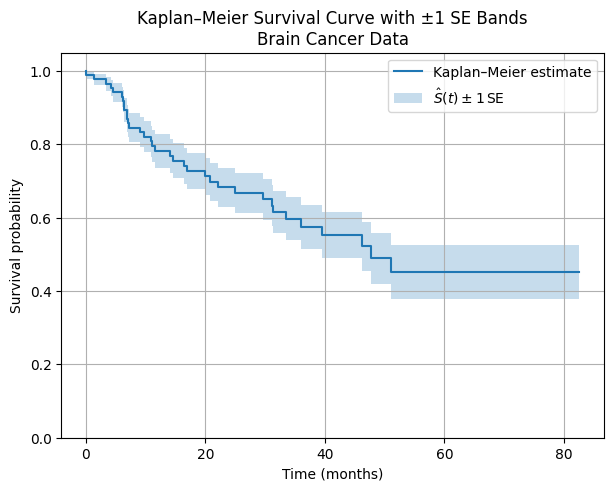

In [2]:
# Load data
BrainCancer = load_data("BrainCancer")

durations = BrainCancer["time"].values
events = BrainCancer["status"].values   # 1 = death, 0 = censored

# Fit Kaplan–Meier estimator
kmf = KaplanMeierFitter()
kmf.fit(durations=durations, event_observed=events, label="Kaplan–Meier")

# --- Greenwood standard errors ----------------------------------------------
# event_table has index = times, columns: 'at_risk', 'observed', 'censored', ...
ev_tab = kmf.event_table

n = ev_tab["at_risk"].values        # n_i
d = ev_tab["observed"].values       # d_i
S = kmf.survival_function_["Kaplan–Meier"].values  # \hat S(t_j)

# Greenwood sum: cumulative sum of d_i / [n_i (n_i - d_i)]
term = np.zeros_like(d, dtype=float)
mask = (n > 0) & (n - d > 0)        # avoid division by zero at the very end
term[mask] = d[mask] / (n[mask] * (n[mask] - d[mask]))

greenwood_sum = np.cumsum(term)
var_S = (S ** 2) * greenwood_sum
se_S = np.sqrt(var_S)

# Construct ± 1 SE bands, truncated to [0, 1]
lower = np.clip(S - se_S, 0, 1)
upper = np.clip(S + se_S, 0, 1)
t = kmf.survival_function_.index

# --- Plot KM curve with ±1 SE bands -----------------------------------------
plt.figure(figsize=(7, 5))
plt.step(t, S, where="post", label="Kaplan–Meier estimate")
plt.fill_between(t, lower, upper, step="post", alpha=0.25,
                 label=r"$\hat S(t) \pm 1\,\mathrm{SE}$")

plt.xlabel("Time (months)")
plt.ylabel("Survival probability")
plt.ylim(0, 1.05)
plt.title("Kaplan–Meier Survival Curve with ±1 SE Bands\nBrain Cancer Data")
plt.legend()
plt.grid(True)
plt.show()

### (b) Draw a bootstrap sample of size $n = 88$ from the pairs $(y_i, \delta_i)$, and compute the resulting Kaplan-Meier survival curve. Repeat this process $B = 200$ times. Use the results to obtain an estimate of the standard error of the Kaplan-Meier survival curve at each timepoint. Compare this to the standard errors obtained in (a).

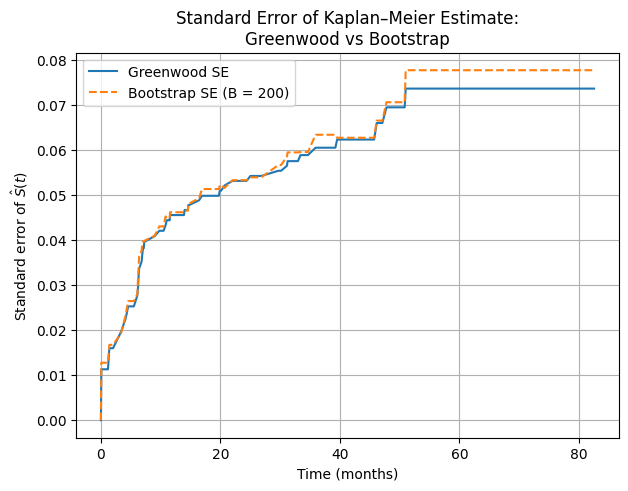

In [3]:
# -------------------------------------------------------------------
# Original KM fit and Greenwood standard errors (from part a)
# -------------------------------------------------------------------
durations = BrainCancer["time"].values
events = BrainCancer["status"].values   # 1 = death, 0 = censored
n = len(BrainCancer)                    # should be 88

kmf = KaplanMeierFitter()
kmf.fit(durations, events)

# Time grid and KM estimate
t_grid = kmf.survival_function_.index.values
S_hat = kmf.survival_function_.iloc[:, 0].values

# Greenwood SE
ev_tab = kmf.event_table
n_at_risk = ev_tab["at_risk"].values
d_obs = ev_tab["observed"].values

term = np.zeros_like(d_obs, dtype=float)
mask = (n_at_risk > 0) & (n_at_risk - d_obs > 0)
term[mask] = d_obs[mask] / (n_at_risk[mask] * (n_at_risk[mask] - d_obs[mask]))

greenwood_sum = np.cumsum(term)
var_greenwood = (S_hat ** 2) * greenwood_sum
se_greenwood = np.sqrt(var_greenwood)

# -------------------------------------------------------------------
# Bootstrap estimate of the standard error of S(t)
# -------------------------------------------------------------------
B = 200
boot_surv = np.empty((B, len(t_grid)))

rng = np.random.default_rng(seed=123)   # fix seed for reproducibility

for b in range(B):
    # sample n pairs (time, status) with replacement
    idx = rng.integers(low=0, high=n, size=n)
    durations_b = durations[idx]
    events_b = events[idx]

    kmf_b = KaplanMeierFitter()
    kmf_b.fit(durations_b, events_b)

    # Evaluate the bootstrap KM curve on the original time grid
    boot_surv[b, :] = kmf_b.predict(t_grid)

# Bootstrap SE at each time point:
#   \widehat{\mathrm{SE}}_\text{boot}(\hat S(t_j))
se_boot = boot_surv.std(axis=0, ddof=1)

# -------------------------------------------------------------------
# Compare Greenwood vs bootstrap SEs
# -------------------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.plot(t_grid, se_greenwood, label="Greenwood SE", linestyle="-")
plt.plot(t_grid, se_boot, label="Bootstrap SE (B = 200)", linestyle="--")

plt.xlabel("Time (months)")
plt.ylabel(r"Standard error of $\hat S(t)$")
plt.title("Standard Error of Kaplan–Meier Estimate:\nGreenwood vs Bootstrap")
plt.legend()
plt.grid(True)
plt.show()


### (c) Fit a Cox proportional hazards model that uses all of the predictors to predict survival. Summarize the main findings.

In [10]:
# Create design matrix: all predictors, with dummy variables for categoricals
X = BrainCancer.drop(columns=["time", "status"])
X = pd.get_dummies(X, drop_first=True)

# Combine with survival outcome
df_cox = pd.concat([BrainCancer[["time", "status"]], X], axis=1)

# Fit Cox proportional hazards model
cph = CoxPHFitter()
cph.fit(df_cox, duration_col="time", event_col="status")

# Show summary (coefficients, SE, z, p, etc.)
#cph.print_summary()
cph.summary


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
ki,-0.061785,0.940085,0.066401,-0.191929,0.068358,0.825366,1.070748,0.0,-0.930491,0.352117,1.505874
gtv,0.036053,1.036711,0.022638,-0.008316,0.080422,0.991719,1.083744,0.0,1.592622,0.111245,3.168189
ki_group,0.004556,1.004567,0.075340,-0.143107,0.152220,0.866661,1.164416,0.0,0.060477,0.951776,0.071306
sex_Male,0.101372,1.106689,0.365738,-0.615461,0.818206,0.540392,2.266431,0.0,0.277172,0.781648,0.355409
diagnosis_LG glioma,-1.088534,0.336710,0.575780,-2.217043,0.039974,0.108931,1.040783,0.0,-1.890539,0.058686,4.090841
diagnosis_Meningioma,-2.074319,0.125642,0.471239,-2.997930,-1.150708,0.049890,0.316413,0.0,-4.401842,0.000011,16.507510
diagnosis_Other,-1.226068,0.293444,0.645976,-2.492157,0.040022,0.082731,1.040834,0.0,-1.898008,0.057695,4.115408
loc_Supratentorial,0.380002,1.462287,0.701360,-0.994639,1.754642,0.369857,5.781377,0.0,0.541807,0.587952,0.766231
stereo_SRT,0.137370,1.147253,0.599667,-1.037956,1.312696,0.354178,3.716181,0.0,0.229078,0.818809,0.288402


**Solution** : We fitted a Cox proportional hazards model with all predictors (`sex`, `diagnosis`, `loc`, `ki`, `gtv`, `stereo`) to the brain–cancer survival data (`time`, `status`).

- The global **likelihood ratio test** is highly significant (\\(\chi^2 = 39.5\\) on 8 d.f., very small \\(p\\)-value), indicating that the covariates jointly have a strong association with survival. The model’s **concordance index** is 0.79, showing good discriminative ability.

- **Karnofsky index (`ki`)** has a negative coefficient (\\(\hat\beta = -0.06\\), \\(p < 0.005\\)), with hazard ratio \\(\exp(\hat\beta) = 0.94\\) (95\% CI: 0.91–0.98).
  Each 1-point increase in `ki` multiplies the hazard by about 0.94, i.e., **better performance status is strongly associated with a lower instantaneous risk of death**.

- **Diagnosis** is also strongly related to survival. The reference category is **high-grade glioma (HG glioma)**.
  Compared with HG glioma:
  - **Meningioma** has \\(\hat\beta = -2.08\\), \\(\exp(\hat\beta) = 0.12\\) (95\% CI: 0.05–0.30, \\(p < 0.005\\)), meaning the hazard is about **88% lower** than for HG glioma.
  - **Other** diagnoses have \\(\exp(\hat\beta) = 0.29\\) (95\% CI: 0.09–0.99, \\(p \approx 0.05\\)), also indicating a substantially lower hazard.
  - **Low-grade glioma (LG glioma)** shows a reduced hazard (\\(\exp(\hat\beta) = 0.34\\), 95\% CI: 0.11–1.03, \\(p \approx 0.06\\)), with borderline statistical significance.

  Overall, patients with **HG glioma** have the worst prognosis, while those with **meningioma** (and to a lesser extent “other” and LG glioma) have much better survival.

- The remaining covariates show no clear evidence of association with survival after adjustment for the above:
  - **Tumor volume (`gtv`)** has a small positive effect (\\(\exp(\hat\beta) = 1.04\\), 95\% CI: 0.99–1.08, \\(p = 0.11\\)).
  - **Sex (Male vs Female)**, **tumor location** (supratentorial vs infratentorial), and **stereotactic method** (SRT vs SRS) have hazard ratios close to 1 with wide confidence intervals and large \\(p\\)-values (\\(p > 0.5\\)), suggesting **no strong independent effect** on survival in this dataset.

**In summary**, the Cox model indicates that survival is primarily driven by **diagnosis type** and **Karnofsky index**, with high-grade glioma and poor functional status associated with markedly worse outcomes, whereas sex, tumor location, stereotactic method, and tumor volume play at most a minor role once these variables are taken into account.

### (d) Stratify the data by the value of \\(k_i\\). (Since only one observation has \\(k_i==40\\), you can group that observation together with the observations that have \\(k_i==60\\).) Plot Kaplan-Meier survival curves for each of the five strata, adjusted for the other predictors.

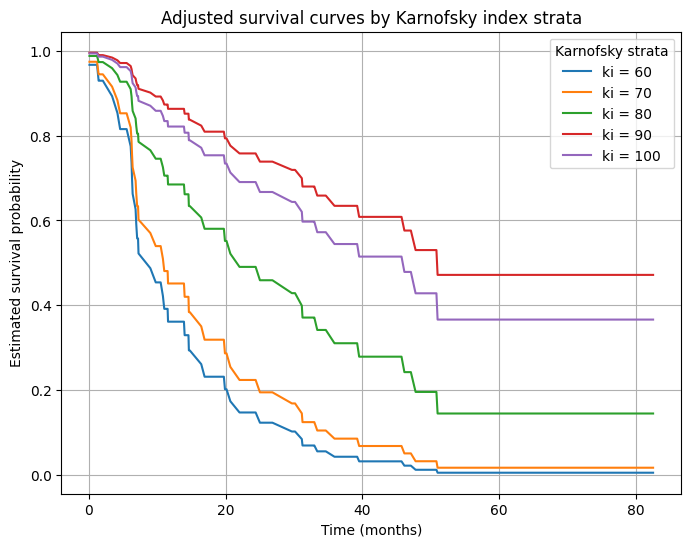

In [5]:
# -------------------------------------------------------------
# 1. Load data and create Karnofsky strata (5 levels)
#    Group ki == 40 together with ki == 60
# -------------------------------------------------------------

BrainCancer["ki_group"] = BrainCancer["ki"].replace({40: 60})
ki_levels = np.sort(BrainCancer["ki_group"].unique())   # e.g. [60, 70, 80, 90, 100]

# -------------------------------------------------------------
# 2. Fit a Cox model with all predictors, using numeric/dummy
#    covariates (this will be used to get adjusted survival curves)
# -------------------------------------------------------------
# Keep original predictors, but drop the numeric ki (we now use ki_group)
predictors = ["sex", "diagnosis", "loc", "stereo", "gtv", "ki_group"]

df = BrainCancer[predictors + ["time", "status"]].copy()
df["ki_group"] = df["ki_group"].astype("category")

# Dummy-code categorical predictors (including ki_group)
X = pd.get_dummies(df.drop(columns=["time", "status"]), drop_first=True)
df_cox = pd.concat([df[["time", "status"]], X], axis=1)

cph = CoxPHFitter()
cph.fit(df_cox, duration_col="time", event_col="status")

# -------------------------------------------------------------
# 3. Build representative covariate profiles:
#    - For each ki stratum, set ki_group to that value
#    - Other predictors set to mean (numeric) or mode (categorical)
# -------------------------------------------------------------
rep = {
    "gtv": BrainCancer["gtv"].mean(),
    "sex": BrainCancer["sex"].mode()[0],
    "diagnosis": BrainCancer["diagnosis"].mode()[0],
    "loc": BrainCancer["loc"].mode()[0],
    "stereo": BrainCancer["stereo"].mode()[0],
}

profiles = []
index_names = []

for k in ki_levels:
    row = rep.copy()
    row["ki_group"] = k
    profiles.append(row)
    index_names.append(f"ki = {k}")

profiles = pd.DataFrame(profiles)
profiles["ki_group"] = profiles["ki_group"].astype("category")
profiles.index = index_names

# Dummy-code profiles using the SAME encoding as the Cox model
profiles_dummies = pd.get_dummies(profiles, drop_first=True)
profiles_dummies = profiles_dummies.reindex(
    columns=df_cox.drop(columns=["time", "status"]).columns,
    fill_value=0,
)

# -------------------------------------------------------------
# 4. Predict survival curves for each ki stratum (adjusted for
#    the other predictors) and plot them
# -------------------------------------------------------------
surv_curves = cph.predict_survival_function(profiles_dummies)

fig, ax = plt.subplots(figsize=(8, 6))
surv_curves.plot(ax=ax)

ax.set_xlabel("Time (months)")
ax.set_ylabel("Estimated survival probability")
ax.set_title("Adjusted survival curves by Karnofsky index strata")
ax.legend(title="Karnofsky strata")
ax.grid(True)

plt.show()
